<a href="https://colab.research.google.com/github/Jiggy205/Ceasar-Cypher/blob/main/MVP_stats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

My dataset is a set of all of the NBA MVPs every year, with most relevent stats. My goal is to answer the question: "who had the best MVP season statistically". I intend to show an individual stat, the sum of all the major stats, and a part where you can input  two players to see their stats and compare them.
My hypothesis is:
I think players have gotten worse over time with better stats from mvps in older years.

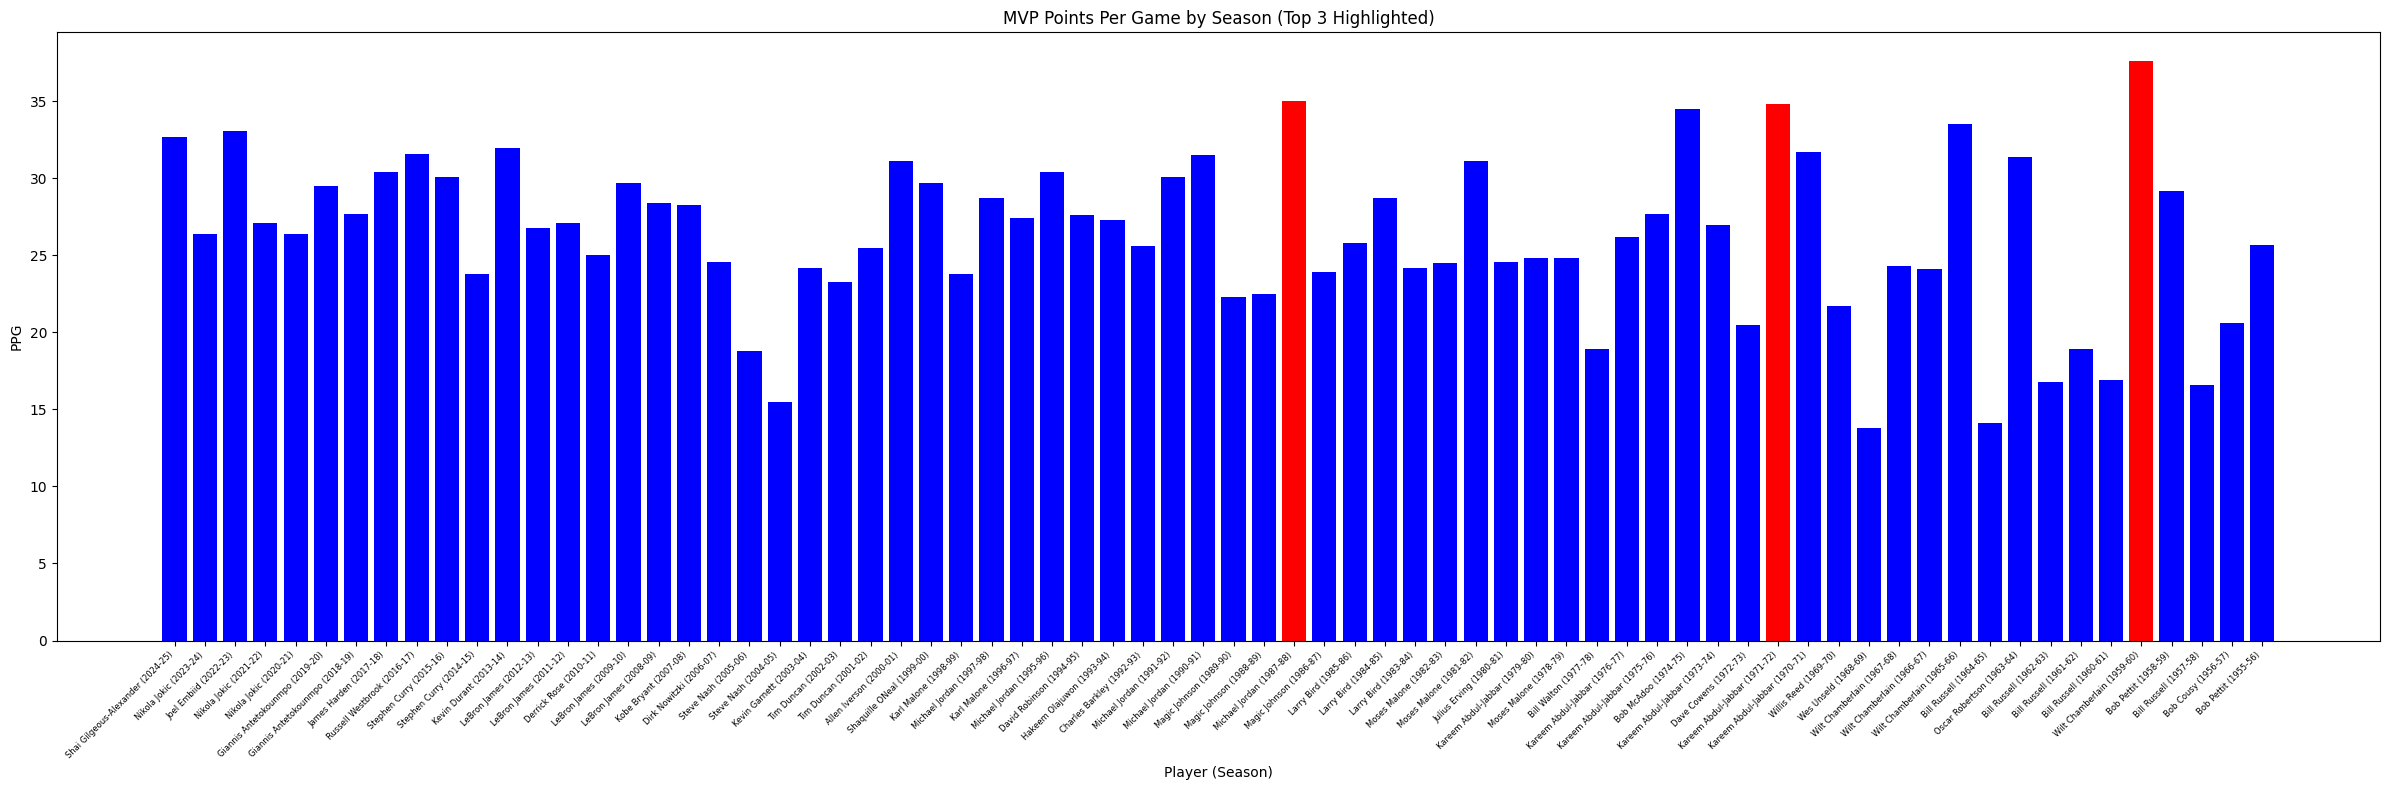

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import csv

with open("mvp_data.csv", "r") as f:
  reader = csv.reader(f)
  headings = next(reader)

  rows = []
  for row in reader:
    rows.append(row)



  players = []
  for row in rows:
    players.append(row[2] + " (" + row[0] + ")")

  pts = []
  for row in rows:
    try:
      pts.append(float(row[8]))
    except:
        pts.append(0)

  trb = []
  for row in rows:
    try:
        trb.append(float(row[9]))
    except:
        trb.append(0)

  ast = []
  for row in rows:
      try:
          ast.append(float(row[10]))
      except:
          ast.append(0)

  stl = []
  for row in rows:
      try:
         stl.append(float(row[11]))
      except:
          stl.append(0)

  blk = []
  for row in rows:
    try:
          blk.append(float(row[12]))
    except:
          blk.append(0)
  total = []
  for i in range(len(rows)):
    total.append(pts[i] + trb[i] + ast[i] + stl[i] + blk[i])
  top3 = sorted(pts, reverse=True)[:3]
  Top3 = sorted(total, reverse=True)[:3]
  top7 = sorted(total, reverse=True)[3:7]
  color2 = []
  for t in total:
    if t in Top3:
      color2.append("red") #colors the top 3 red
    elif t in top7:
      color2.append("green") # colors the next 4 green
    else:
      color2.append("blue") #colors the rest blue

  colors = []
  for p in pts:
      if p in top3:
          colors.append("red") #colors the top 3 red
      else:
          colors.append("blue") #colors the rest blue

  plt.figure(figsize=(24, 8))
  plt.bar(players, pts, color=colors)
  plt.title("MVP Points Per Game by Season (Top 3 Highlighted)")
  plt.xlabel("Player (Season)")
  plt.ylabel("PPG")
  plt.xticks(rotation=45, ha="right", fontsize=6)
  plt.tight_layout()
  plt.show()

After this, I am making progress on my hypothesis, and I was correct. However, the lowest points are also mostly in the early years (aside from 04-05 Steve Nash). But, since points arent the only stat, I am going to look at the sum of each players stats in pts, trb, ast, stl, and blks. Again, the top three will be highlighted in red, and this time, 4-7 will be green

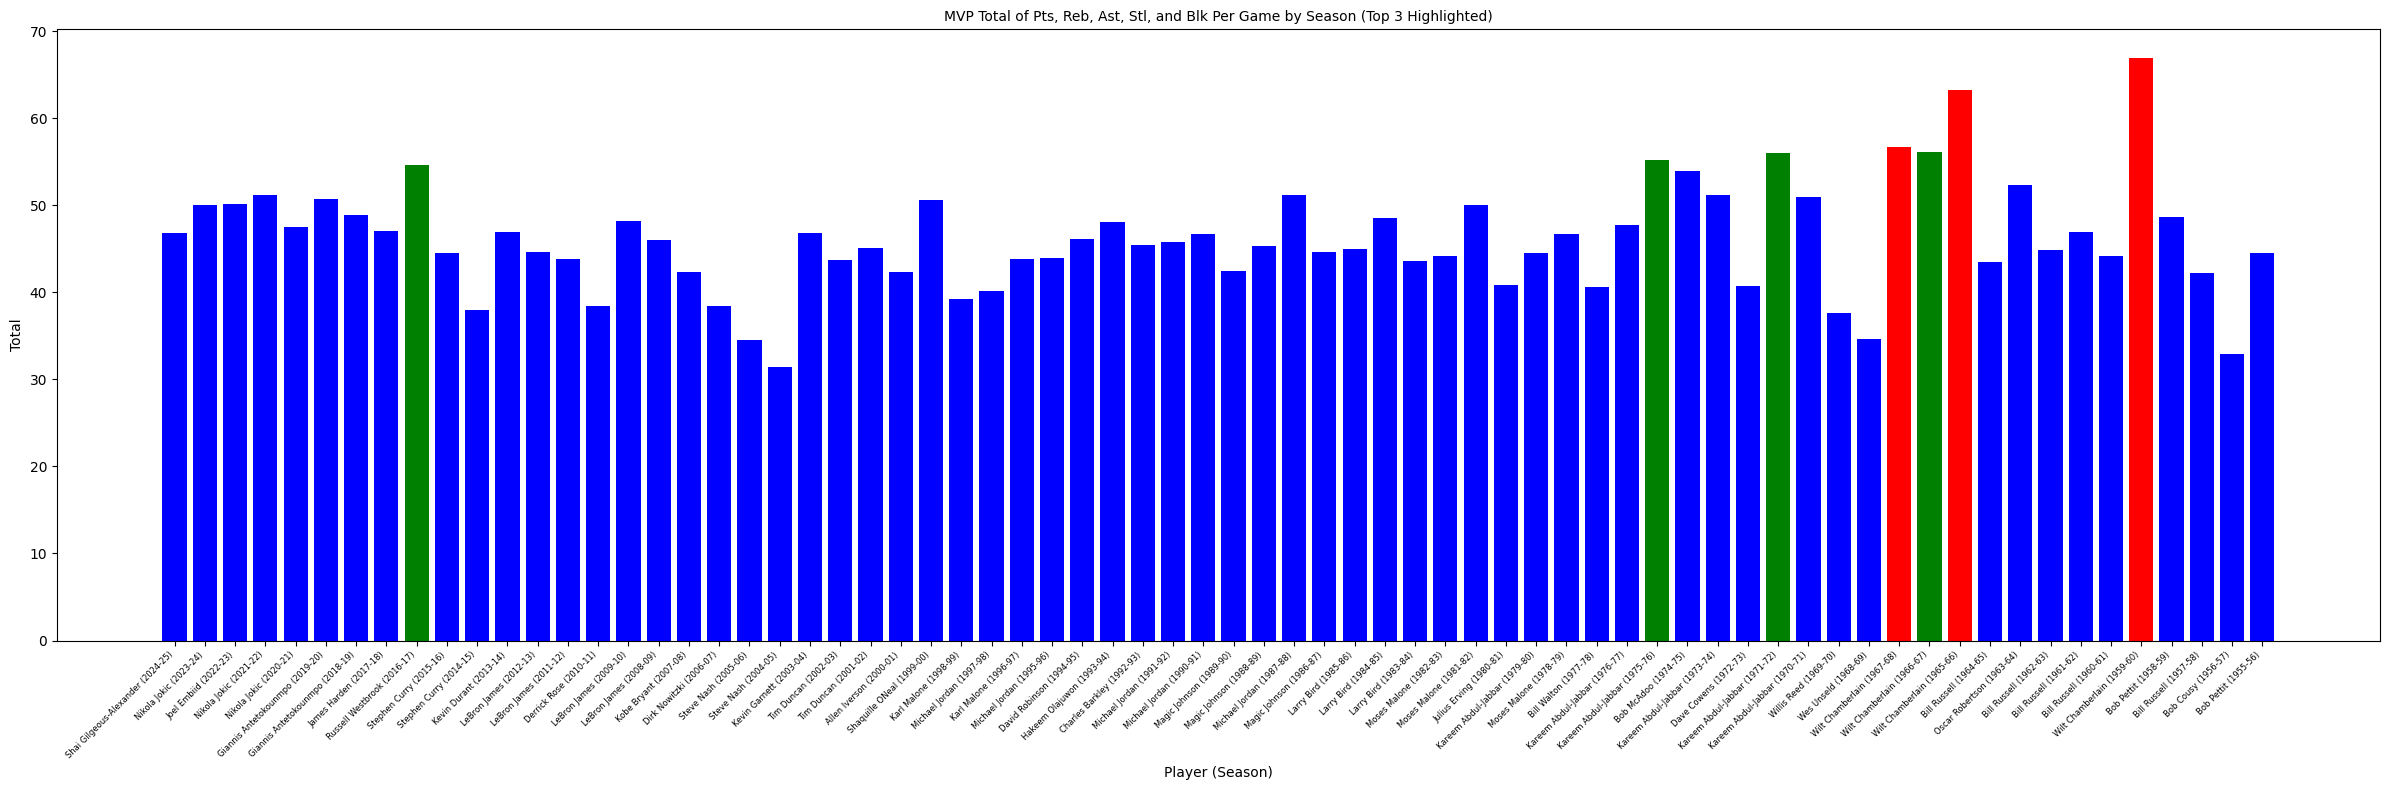

In [ ]:
  plt.figure(figsize=(24, 8))
  plt.bar(players, total, color=color2)
  plt.title("MVP Total of Pts, Reb, Ast, Stl, and Blk Per Game by Season (Top 3 Highlighted)", fontsize=10)
  plt.xlabel("Player (Season)")
  plt.ylabel("Total")
  plt.xticks(rotation=45, ha="right", fontsize=6)
  plt.tight_layout()
  plt.show()

This further proves my point, with 6 of the top seven highest being Wilt and Kareem, and Wilt being the top four. However, there is a major anomaly with 16-17 Russel Westbrook being in seventh. The fact that Westbrick is in this list is normally surprising, but since he averaged a triple double, Im not surpised. (https://www.youtube.com/watch?v=Dtb10PeLF2s)
 finally, I am going to allow for comapring 2 selected players.

Enter first player: jordan
Enter second player: james
Multiple matches:
1: Michael Jordan (1997-98)
2: Michael Jordan (1995-96)
3: Michael Jordan (1991-92)
4: Michael Jordan (1990-91)
5: Michael Jordan (1987-88)
Pick a number: 2
Multiple matches:
1: James Harden (2017-18)
2: LeBron James (2012-13)
3: LeBron James (2011-12)
4: LeBron James (2009-10)
5: LeBron James (2008-09)
Pick a number: 3


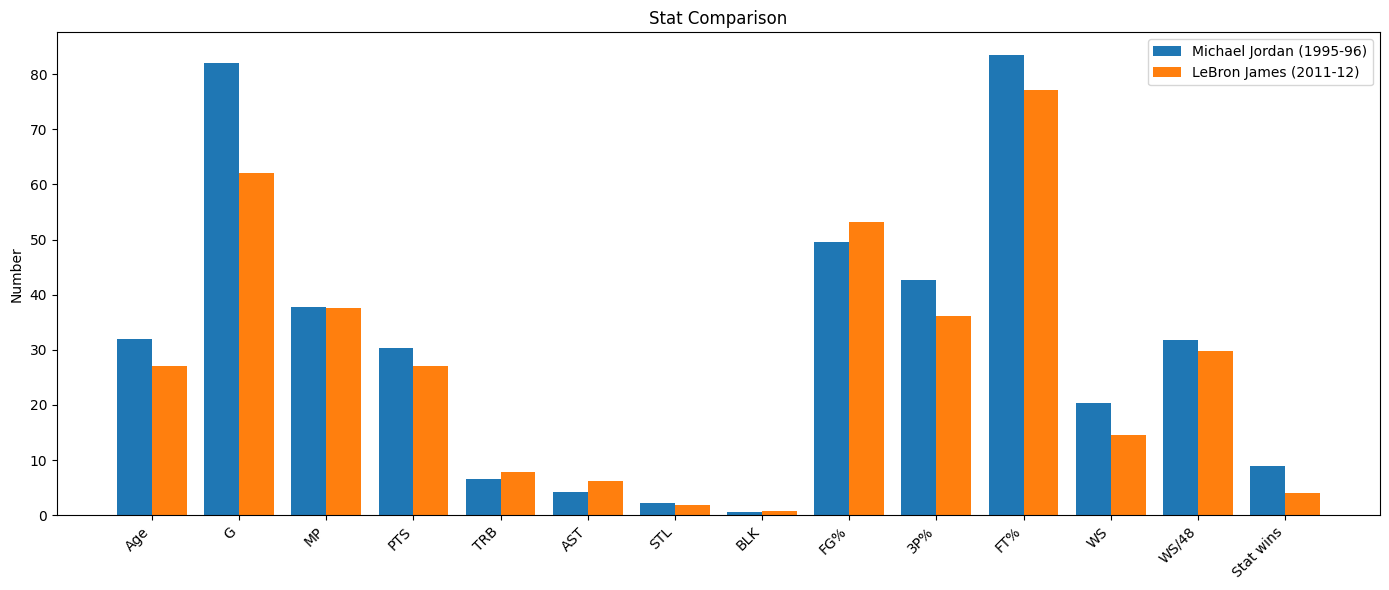

In [ ]:
  player_input1 = input("Enter first player: ")
player_input2 = input("Enter second player: ")

player1_matches = [i for i in range(len(players)) if player_input1.lower() in players[i].lower()]
player2_matches = [i for i in range(len(players)) if player_input2.lower() in players[i].lower()]

# player 1 selection
if len(player1_matches) > 1:
    print("Multiple matches:")
    for idx, i in enumerate(player1_matches):
        print(f"{idx + 1}: {players[i]}")
    choice = int(input("Pick a number: "))
    player1_index = player1_matches[choice - 1]

else: #if the input isnt a player
    if not player1_matches:
        print(f"'{player_input1}' isn't a player")
        raise ValueError(f"'{player_input1}' doesnt work")
    player1_index = player1_matches[0]

# player 2 selection
if len(player2_matches) > 1:
    print("Multiple matches:")
    for idx, i in enumerate(player2_matches):
        print(f"{idx + 1}: {players[i]}")
    choice = int(input("Pick a number: "))
    player2_index = player2_matches[choice - 1]

else: #if the input isnt a player
    if not player2_matches:
        print(f"'{player_input2}' isn't a player")
        raise ValueError(f"'{player_input2}' doesnt work")
    player2_index = player2_matches[0]


stat_column_indexes = []
stat_names = []

for col in range(len(headings)):
    try:
        float(rows[0][col])
        stat_column_indexes.append(col)
        stat_names.append(headings[col])
    except:
        pass

# get stats
player1_stats = []
player2_stats = []

for i in range(len(stat_column_indexes)):
    col_index = stat_column_indexes[i]
    stat_name = stat_names[i]

    try:
        val1 = float(rows[player1_index][col_index])
    except:
        val1 = 0

    try:
        val2 = float(rows[player2_index][col_index])
    except:
        val2 = 0

    # fix percents and ws per 48 to be easier to read
    if "%" in stat_name or "/" in stat_name:
        val1 *= 100
        val2 *= 100

    player1_stats.append(val1)
    player2_stats.append(val2)


player1_wins = 0
player2_wins = 0

for i in range(len(player1_stats)):
    if player1_stats[i] > player2_stats[i]:
        player1_wins += 1
    elif player2_stats[i] > player1_stats[i]:
        player2_wins += 1

player1_stats.append(player1_wins)
player2_stats.append(player2_wins)
stat_names.append("Stat wins")


x_positions = range(len(stat_names))

plt.figure(figsize=(14, 6))
plt.bar(x_positions, player1_stats, width=0.4, label=players[player1_index])
plt.bar([x + 0.4 for x in x_positions], player2_stats, width=0.4, label=players[player2_index]) #+0.4 for spacing

plt.xticks([x + 0.2 for x in x_positions] , stat_names, rotation=45, ha="right")#+0.2 for spacing
plt.title("Stat Comparison")
plt.ylabel("Number")
plt.legend()
plt.tight_layout()
plt.show()

My dynamic graph proves that older players as mvps were statistically better than newer ones. Just by compairing almost any of wilts seasons with most newer seasons further proves my hypothesis. Go ahead, try it yourself, some of the results are surprising.

In conclusion, my hypothesis is correct. If you compare most older players to newer ones, even with the fact that most older players didnt or even couldnt shoot threes, the results are still the same. This is an issue, because players should be getting better, however, playtime per player is usually lower in newer players, but with older players it is the opposite. For example, in the '61-'62 season, even though he wasnt mvp, wilt averaged 48.5 minutes a game, missing only 8 minutes in the whole season, averaging 50.4pts and 25.7reb, and (allegedlly) scoring 100 points in a single game. The fact that he didnt win MVP proves a more important but more difficult to figure out point, what if the best statistical season of all time didnt win the MVP award?